### Sequence based enrichment between sets of sequences
- e.g. dCREs vs not dCREs using ReMap2022
- e.g. CREs from SCREEN and the dCREs vs the other sequences

#### Installation as mentioned in the vignette is not possible

In [ ]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("regioneReloaded")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.26), R 4.3.3 (2024-02-29)

Installing package(s) 'BiocVersion', 'regioneReloaded'

Warning message:
“dependencies ‘Matrix’, ‘MASS’ are not available”
also installing the dependencies ‘formatR’, ‘lambda.r’, ‘futile.options’, ‘abind’, ‘SparseArray’, ‘futile.logger’, ‘snow’, ‘codetools’, ‘BH’, ‘cpp11’, ‘MatrixGenerics’, ‘Biobase’, ‘S4Arrays’, ‘DelayedArray’, ‘bitops’, ‘BiocParallel’, ‘Rhtslib’, ‘SummarizedExperiment’, ‘rjson’, ‘yaml’, ‘sys’, ‘rprojroot’, ‘lattice’, ‘BiocGenerics’, ‘XVector’, ‘cachem’, ‘BiocIO’, ‘matrixStats’, ‘Rsamtools’, ‘XML’, ‘zlibbioc’, ‘RCurl’, ‘GenomicAlignments’, ‘restfulr’, ‘GenomeInfoDbData’, ‘askpass’, ‘RcppTOML’, ‘here’, ‘png’, ‘rappdirs’, ‘RcppEi

In [2]:
library("regioneReloaded")

ERROR: Error in library("regioneReloaded"): there is no package called ‘regioneReloaded’


### Using the gitrepo because one issue since half a year is that the conda version is outdated and using chatgpt to help installing the package
```bash
conda install -c conda-forge -c bioconda \
  r-base=4.3.3 \
  r-devtools \
  r-xml \
  r-rcurl \
  r-httr \
  r-ggplot2 \
  r-ggrepel \
  r-png \
  r-reticulate \
  r-rspectra \
  r-mgcv \
  r-umap \
  bioconductor-xvector \
  bioconductor-summarizedexperiment \
  bioconductor-rtracklayer \
  bioconductor-rsamtools \
  bioconductor-genomicranges \
  bioconductor-genomicalignments \
  bioconductor-genomeinfodb \
  bioconductor-delayedarray \
  bioconductor-biostrings \
  bioconductor-bsgenome \
  bioconductor-s4arrays \
  bioconductor-regioneR \
  bioconductor-regioneReloaded
```

In [ ]:
library(devtools)

In [4]:
devtools::load_all("/home/kisa/coding/regioneReloaded")

ℹ Loading regioneReloaded
Loading required package: regioneR

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required

### Starting with the vignette

In [6]:
data("cw_Alien")
cw_Alien_ReG <- makeCrosswiseMatrix(cw_Alien_ReG, pvcut = 1)

[1] "method selected for hclustering: average"
 complete   average    single   ward.D2    median  centroid  mcquitty 
0.7497654 0.7857181 0.6514804 0.7363304 0.3459672 0.4561003 0.7516609 


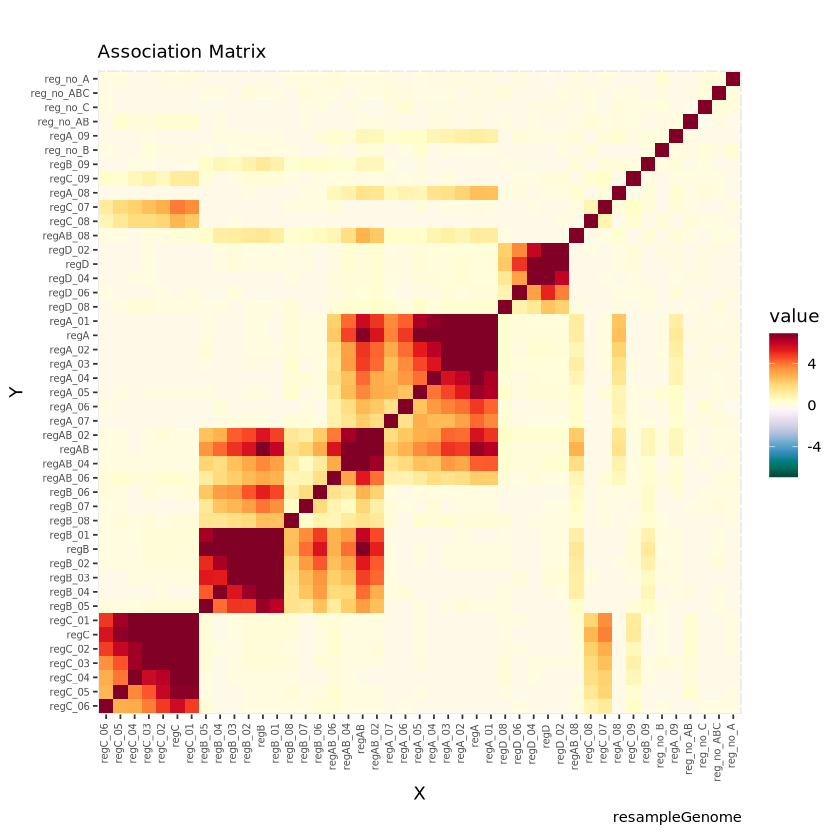

In [7]:
plotCrosswiseMatrix(cw_Alien_ReG)


#### Alien genome

In [5]:
AlienGenome <-
    toGRanges(data.frame(
        chr = c("AlChr1", "AlChr2", "AlChr3", "AlChr4"),
        start = c(rep(1, 4)),
        end = c(2e6, 1e6, 5e5, 1e5)
    ))

# text

gnm <- AlienGenome

nreg <- 100

regA <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = gnm
    )

regB <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = gnm
    )

regC <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = gnm
    )

# text2

vectorPerc <- seq(0.1, 0.9, 0.1)

RsetA <-
    similarRegionSet(
        GR = regA,
        name = "regA",
        genome = gnm,
        vectorPerc = vectorPerc
    )
RsetB <-
    similarRegionSet(
        GR = regB,
        name = "regB",
        genome = gnm,
        vectorPerc = vectorPerc
    )
RsetC <-
    similarRegionSet(
        GR = regC,
        name = "regC",
        genome = gnm,
        vectorPerc = vectorPerc
    )

# text3
vectorPerc2 <- seq(0.2, 0.8, 0.2)
regAB <- c(sample(regA, nreg / 2), sample(regB, nreg / 2))
RsetAB <-
    similarRegionSet(
        GR = regAB,
        name = "regAB",
        genome = gnm,
        vectorPerc = vectorPerc2
    )

# text4

reg_no_A <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = subtractRegions(gnm, regA)
    )

reg_no_B <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = subtractRegions(gnm, regB)
    )

reg_no_C <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = subtractRegions(gnm, regC)
    )

reg_no_AB <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = subtractRegions(gnm, c(regA, regB))
    )

reg_no_ABC <-
    createRandomRegions(
        nregions = nreg,
        length.mean = 100,
        length.sd = 50,
        non.overlapping = TRUE,
        genome = subtractRegions(gnm, c(regA, regB, regC))
    )

# text5

dst <- sample(c(-300, 300), length(regA), replace = TRUE)
regD <- regioneR::toGRanges(
    data.frame(
        chr = as.vector(GenomeInfoDb::seqnames(regA)),
        start = start(regA) + dst,
        end = end(regA) + dst
    )
)

RsetD <-
    similarRegionSet(
        GR = regD,
        name = "regD",
        genome = gnm,
        vectorPerc = vectorPerc2
    )

# text6


Rset_NO <- list(reg_no_A, reg_no_B, reg_no_C, reg_no_AB, reg_no_ABC)

names(Rset_NO) <- c("reg_no_A", "reg_no_B", "reg_no_C", "reg_no_AB", "reg_no_ABC")

AlienRSList_narrow <- c(RsetA, RsetB, RsetC, RsetD, RsetAB, Rset_NO)

summary(AlienRSList_narrow)

           Length Class   Mode
regA_01    100    GRanges S4  
regA_02    100    GRanges S4  
regA_03    100    GRanges S4  
regA_04    100    GRanges S4  
regA_05    100    GRanges S4  
regA_06    100    GRanges S4  
regA_07    100    GRanges S4  
regA_08    100    GRanges S4  
regA_09    100    GRanges S4  
regA       100    GRanges S4  
regB_01    100    GRanges S4  
regB_02    100    GRanges S4  
regB_03    100    GRanges S4  
regB_04    100    GRanges S4  
regB_05    100    GRanges S4  
regB_06    100    GRanges S4  
regB_07    100    GRanges S4  
regB_08    100    GRanges S4  
regB_09    100    GRanges S4  
regB       100    GRanges S4  
regC_01    100    GRanges S4  
regC_02    100    GRanges S4  
regC_03    100    GRanges S4  
regC_04    100    GRanges S4  
regC_05    100    GRanges S4  
regC_06    100    GRanges S4  
regC_07    100    GRanges S4  
regC_08    100    GRanges S4  
regC_09    100    GRanges S4  
regC       100    GRanges S4  
regD_02    100    GRanges S4  
regD_04 

#### 5.1 Crosswise Analysis and the genoMatriXeR object
`crosswisePermTest()` is the main statistical function of the package. “Crosswise” analysis (in contrast to “pairwise”) refers to the calculation of permutation tests between all possible combinations of elements in a first list of region sets (Alist) with those in a second list (Blist). The core statistical calculations of the permutation tests rely on `permTest()`.


The result of `crosswisePermTest()` is stored in an S4 object of class `genoMatriXeR` that contains three slots: parameters, multiOverlaps and matrix.

##### Slot Parameters:

In [8]:
data("cw_Alien")
getParameters(cw_Alien_ReG)

parameter,value
<chr>,<chr>
Alist,AlienRSList_narrow
Blist,AlienRSList_narrow
sampling,FALSE
fraction,0.15
min_sampling,0.15
ranFUN,resampleGenome
evFUN,numOverlaps
ntimes,1000
universe,NULL


##### multiOverlaps:
The “multiOverlaps” slot contains a list of data frames that contain the results of each permutation test performed. For each region set in “Alist”, a data frame is generated with 11 columns and a number of rows equal to the elements in “Blist”. The columns of the data frame contain the following information:


- `order`.id: order of comparison
- `name`: name of region sets in Blist
- `n_regionA`: number of permuted Alist regions
- `n_regionB`: number of regions in each regions set of Blist
- `z_score`: z-score calculated by permTest
- `p_value`: p.value calculated by permTest
- `n_hits`: number of hits computed using the evaluation function on a regions set of Alist versus each regions set of Blists
- `mean_perm_test`: mean of hits computed using the evaluation function on the permutated region set
- `sd_perm_test`: standard deviation of hits computed using the evaluation function on the permutated region set
- `norm_zscore`: normalized z-scores
- `adj_p_value`: adjusted p.value


##### Matrix: 
When the genoMatriXeR object is initially created by running crosswisePermTest(), the “matrix” slot will have a NULL value. See the section Matrix calculation and visualization on how to generate, access and visualize the association matrix.

#### Matrix Calculation and visualization

In [9]:
cw_Alien_RaR <- makeCrosswiseMatrix(cw_Alien_RaR)

[1] "method selected for hclustering: average"
 complete   average    single   ward.D2    median  centroid  mcquitty 
0.7592340 0.7805803 0.6610466 0.7222423 0.0402856 0.5192172 0.7231580 


In [10]:
cw_Alien_ReG <- makeCrosswiseMatrix(cw_Alien_ReG)

[1] "method selected for hclustering: average"
 complete   average    single   ward.D2    median  centroid  mcquitty 
0.7497654 0.7857181 0.6514804 0.7363304 0.3459672 0.4561003 0.7516609 


In [11]:
cw_Alien_ReR <- makeCrosswiseMatrix(cw_Alien_ReR)

[1] "method selected for hclustering: average"
 complete   average    single   ward.D2    median  centroid  mcquitty 
0.7515325 0.7716179 0.6542890 0.7136237 0.2223408 0.5618311 0.7245865 


Fix the order

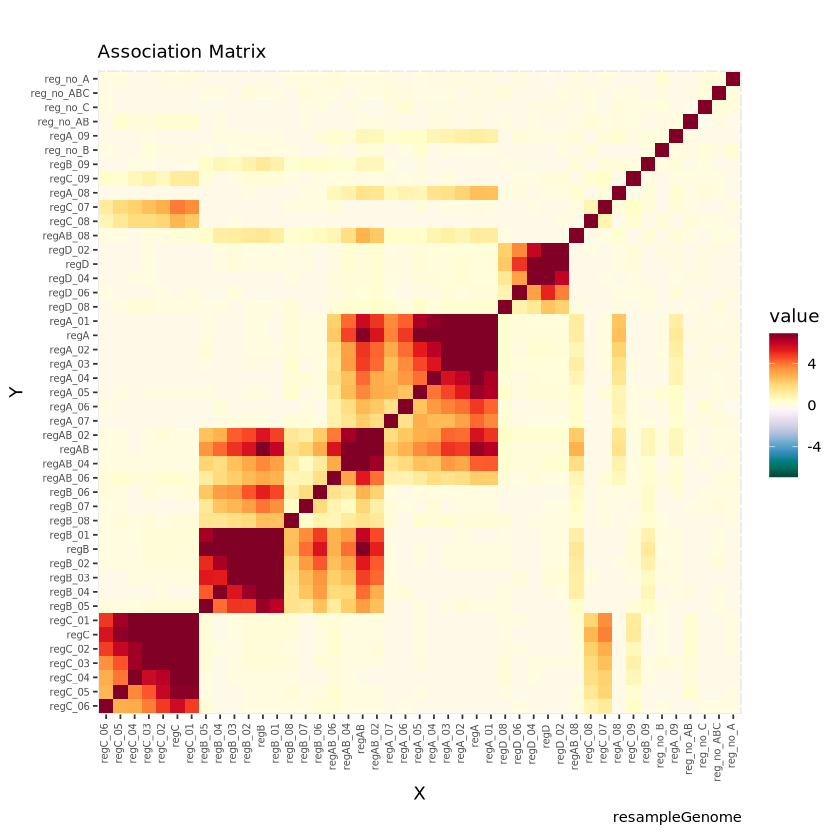

In [13]:
modX <- getHClust(cw_Alien_ReG, hctype = "rows")
modY <- getHClust(cw_Alien_ReG, hctype = "cols")



X <- modX$labels[modX$order]
Y <- modY$labels[modX$order]

ord <- list(X = X, Y = Y)

p_ReG <- plotCrosswiseMatrix(cw_Alien_ReG, matrix_type = "association", ord_mat = ord)
p_ReR <- plotCrosswiseMatrix(cw_Alien_ReR, matrix_type = "association", ord_mat = ord)


plot(p_ReG)

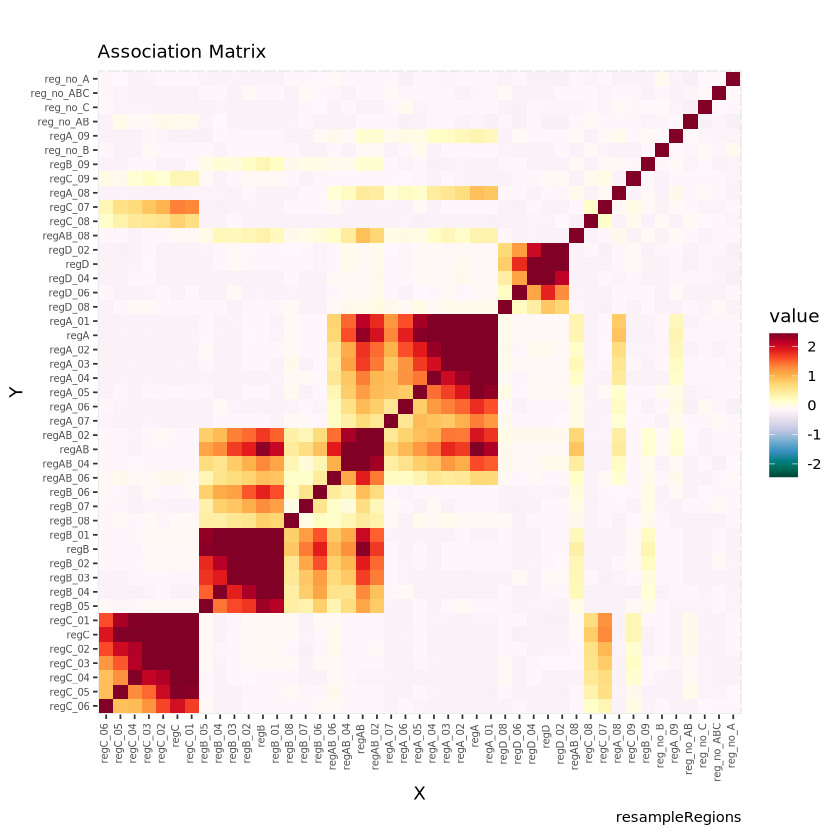

In [14]:
plot(p_ReR)

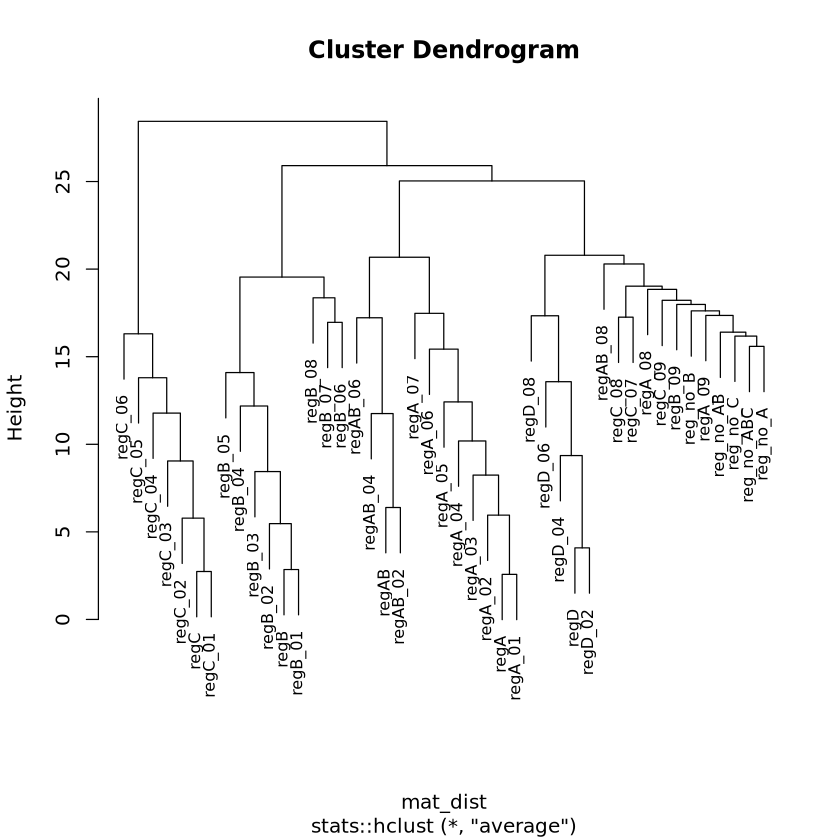

In [15]:
plot(modX, cex = 0.8)

###### Correlation

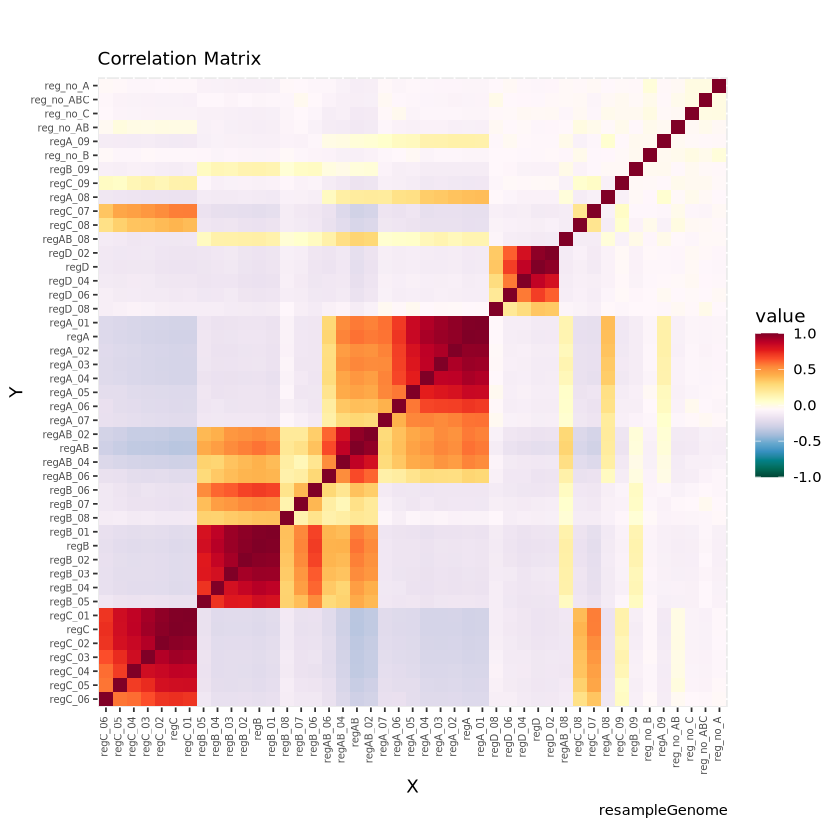

In [16]:
p_ReG_cor <- plotCrosswiseMatrix(cw_Alien_ReG, matrix_type = "correlation", ord_mat = ord)
# p_ReR_cor <- plotCrosswiseMatrix(cw_Alien_ReR, matrix_type = "correlation", ord_mat = ord)

plot(p_ReG_cor)

#### Plot Single permutation test

NULL

Warning message in ggplot2::geom_segment(ggplot2::aes(x = mean.1, y = max_curve/2, :
“All aesthetics have length 1, but the data has 2 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


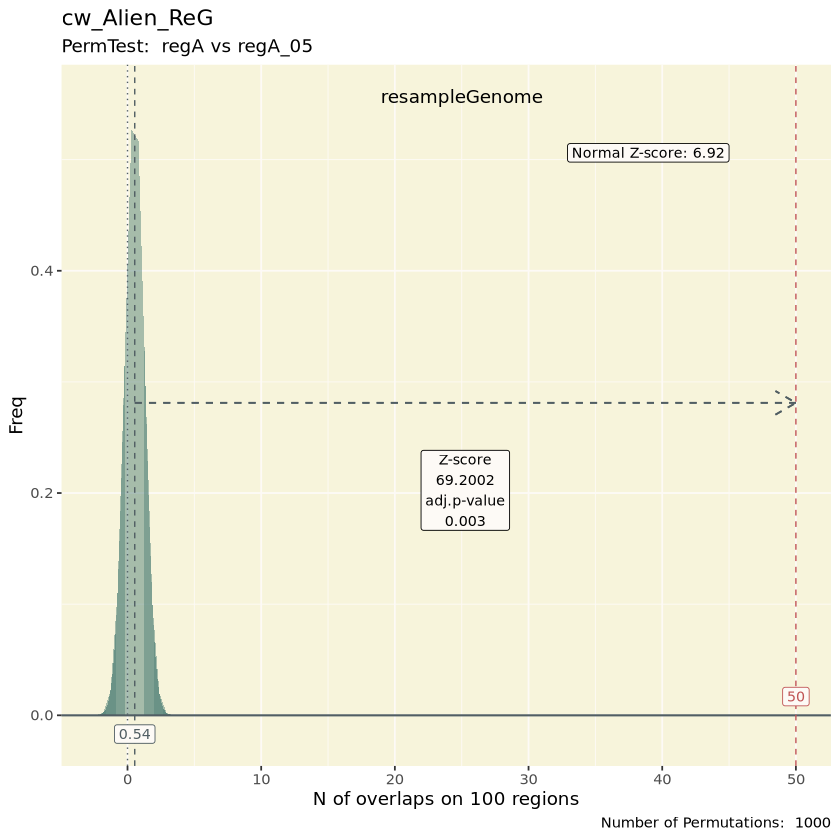

In [17]:
plotSinglePT(cw_Alien_ReG, RS1 = "regA", RS2 = "regA_05")

Warning message in ggplot2::geom_segment(ggplot2::aes(x = mean.1, y = max_curve/2, :
“All aesthetics have length 1, but the data has 2 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


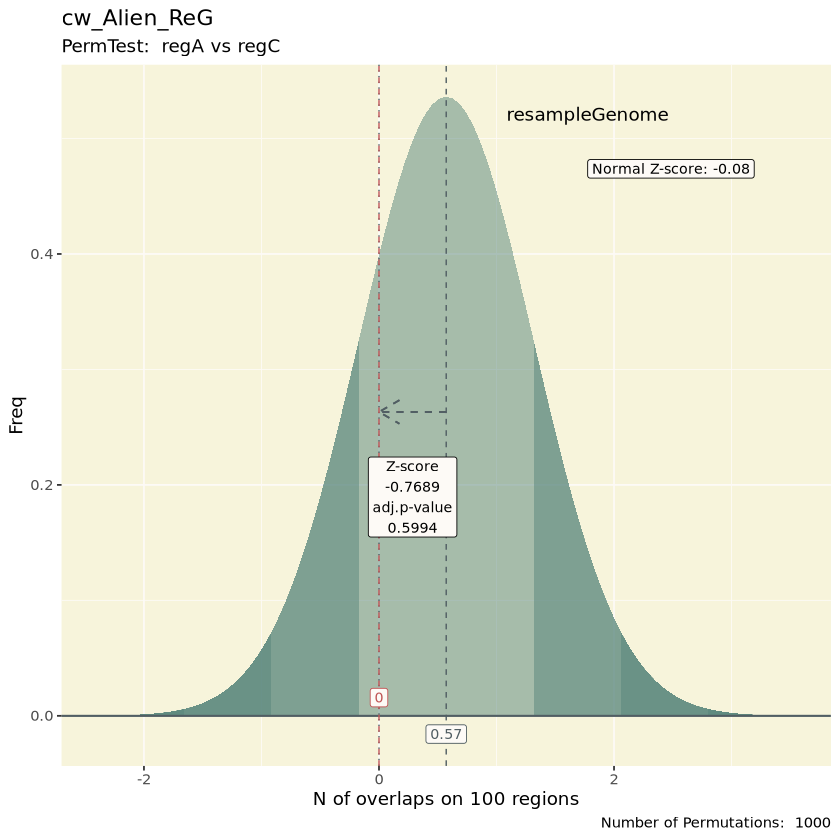

In [ ]:
p_sPT1 <- plotSinglePT(cw_Alien_ReG, RS1 = "regA", RS2 = "regC")

plot(p_sPT1)

Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


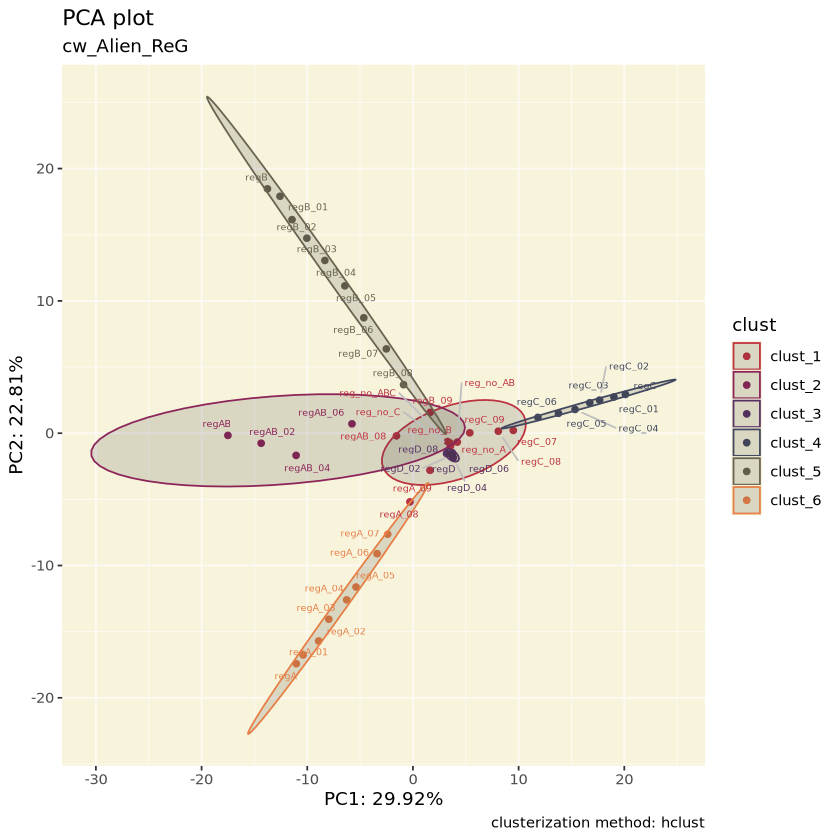

In [25]:
plotCrosswiseDimRed(cw_Alien_ReG, nc = 6, type = "PCA")

In [26]:
.libPaths()

[1] "/home/kisa/miniforge3/envs/updated_r_kernel/lib/R/library"